# Advection-Reaction-Diffusion PDEs

## Full Domain Learning

In [1]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from data_utils import compute_prediction_difference, compute_prediction, extract_targets, extract_TensorDataset, X, U, TIMES
from plot_utils import plot_loss_comp, plot_model_stats, print_model_info, plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, get_animation, plot_points
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import numpy as np
# ----------------------
TRAIN = True
SAVE_PLOTS = True
CROSS_THE_RUBICON = True
ONLY_FINAL_TRAINING = False

PDE = "AdvectionReactionDiffusion/AllenCahn"
PDE_NAME = "Advection-Reaction-Diffusion"
SEED = 42

FIXED = ["IC", "D"]
IC_INDEX = 0
D_INDEX = 0
INDEX = 4
IC = 0 # only if all or nothing fixed
D = 0 # only if all or nothing fixed

N_SOURCES = 5
TIME_SAMPLING = "Const" # Const Log
GENERATION_BC = "Neumann" # Dirichlet Neumann

TIME_INDEXES = [i for i in range(10)] # None
TIME_RESOLUTION = 1

ACTUAL_MODE = "PINN"
N_EPOCHS = 400
LR_MODE = "CosAnn" # CosAnn ExpDec

#SHAPE = {"shape": "circle", "cell_size": 0.02, "center": [0.0, 0.0], "radius": 1.0}
SHAPE = {"shape": "rectangle"}

BC_MODE = "Global"
IC_MODE = "Separated" # Separated Excluded Joined
TRAIN_BC = "Neumann" # Dirichlet Neumann
PDE_AT_BD = False
PDE_AT_T0 = True

FOURIER_FEATURES = False
IC_PARAMS_IN_INPUT = False
PDE_PARAMS_IN_INPUT = False

DWA_MODE = "Std"
CLIP_GRAD = True
# ----------------------
if "PINN" not in ACTUAL_MODE:
    MONITOR_CONFLICTS = False
else:
    MONITOR_CONFLICTS = True

if CLIP_GRAD:
    CLIP = "GradClip"
else:
    CLIP = "NoGradClip"
    
if "IC" in FIXED and "D" in FIXED:
    if IC == D:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/ICD{INDEX}"
        s = "VaryIC_VaryD"
        IC_INDEX = None
        D_INDEX = None
    elif IC < D:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/IC{IC_INDEX}_D{D_INDEX}"
        s = "FixIC_VaryD"
        INDEX = D_INDEX
    else:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/D{D_INDEX}_IC{IC_INDEX}"
        s = "VaryIC_FixD"
        INDEX = IC_INDEX
elif "IC" not in FIXED and "D" not in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/VaryIC_VaryD"
    s = "VaryIC_VaryD"
    IC_INDEX = None
    D_INDEX = None
    INDEX = None
elif "IC" in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/IC{IC_INDEX}_VaryD"
    s = "FixIC_VaryD"
    D_INDEX = None
    INDEX = None
else: # "D" in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/VaryIC_D{D_INDEX}"
    s = "VaryIC_FixD"
    IC_INDEX = None
    INDEX = None

os.makedirs(f"{PDE}/FullDomainLearning/{DIR}", exist_ok=True)

if PDE_PARAMS_IN_INPUT and IC_PARAMS_IN_INPUT:
    DIR += f"/PDE_IC_params_in_input"
elif PDE_PARAMS_IN_INPUT:
    DIR += f"/PDE_params_in_input"
elif IC_PARAMS_IN_INPUT:
    DIR += f"/IC_params_in_input"
else:
    DIR += f"/No_params_in_input"

os.makedirs(f"{PDE}/FullDomainLearning/{DIR}", exist_ok=True)

DIR += f"/{SHAPE['shape']}"
os.makedirs(f"{PDE}/FullDomainLearning/{DIR}", exist_ok=True)

s2 = s
if N_SOURCES is not None:
    s += f"/{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_0-9"
    s2 += f"/{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_10-19"
else:
    s += f"/{TIME_SAMPLING}TimeStep_0-9"
    s2 += f"/{TIME_SAMPLING}TimeStep_10-19"

if "IC" not in FIXED and "D" not in FIXED:
    s += f"/rep0"
    s2 += f"/rep0"
elif "IC" in FIXED and "D" in FIXED:
    if IC == D:
        s += f"/rep0"
        s2 += f"/rep0"
    elif IC < D:
        s += f"/rep{IC_INDEX}"
        s2 += f"/rep{IC_INDEX}"
    else:
        s += f"/rep{D_INDEX}"
        s2 += f"/rep{D_INDEX}"
elif "IC" in FIXED:
    s += f"/rep{IC_INDEX}"
    s2 += f"/rep{IC_INDEX}"
elif "D" in FIXED:
    s += f"/rep{D_INDEX}"
    s2 += f"/rep{D_INDEX}"

BATCH_SIZE_TRAIN = 1024
BATCH_SIZE_DEV = 1024

DATA = f"data/{GENERATION_BC}BC/{SHAPE['shape']}/{s}"
DATA2 = f"data/{GENERATION_BC}BC/{SHAPE['shape']}/{s2}"

full_dataset = None
dev_dataset = None
train_dataset = None
val_dataset = None
intra_test_dataset = None
inter_test_dataset = None

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions

In [2]:
def load_subsets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]]
    ) -> List[ConcatDataset[Subset]]:
    datasetss = []
    for indicess, task_ds in zip(indicesss, dataset):
        datasets = []
        for indices, time_ds in zip(indicess, task_ds.datasets):
            datasets.append(Subset(time_ds, indices))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def load_datasets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]],
        time_resolution: int = 1
    ) -> List[ConcatDataset[TensorDataset]]:
    datasetss = []
    for cds, indicess in zip(dataset, indicesss):
        datasets = []
        for i in range(0, len(indicess), time_resolution):
            ds = cds.datasets[i]
            indices = indicess[i]
        #for ds, indices in zip(cds.datasets, indicess):
            cols = [col[indices] for col in ds.tensors]
            datasets.append(TensorDataset(*cols))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset], time_instants: List[int] = None) -> ConcatDataset:
    if time_instants is None:
        n_snapshots = len(datasets[0].datasets)
        time_instants = [i for i in range(n_snapshots)]
    data = [None for _ in time_instants]
    for i in time_instants:
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

In [3]:
indices = {}
for s in ["dev", "train", "val", "intra_test"]:
    if INDEX is None:
        indices[s] = torch.load(f"{PDE}/{DATA}/{s}_indices.pth")
    else:
        indices[s] = [torch.load(f"{PDE}/{DATA}/{s}_indices.pth")[INDEX]]
    print(f"--------------- {s} set ---------------")
    print(f"n_tasks: {len(indices[s])}")
    print(f"time_instants_per_task: {len(indices[s][0])}")
    print(f"spatial_points_per_time_instant: {len(indices[s][0][0])}")

--------------- dev set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 2048
--------------- train set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 1536
--------------- val set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- intra_test set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512


In [4]:
if INDEX is None:
    full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
else:
    full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]

dev_dataset = load_datasets(full_dataset, indices["dev"])
del full_dataset
full_dataset = None

train_dataset = load_datasets(dev_dataset, indices["train"], TIME_RESOLUTION)
val_dataset = load_datasets(dev_dataset, indices["val"], TIME_RESOLUTION)
del dev_dataset
dev_dataset = None

print(f"n_train_time_instants: {len(train_dataset[0].datasets)}")
print(f"n_val_time_instants: {len(val_dataset[0].datasets)}")

if TIME_INDEXES is not None:
    train_dataset = prepare_dataset(datasets=train_dataset, time_instants=TIME_INDEXES)
    val_dataset = prepare_dataset(datasets=val_dataset, time_instants=TIME_INDEXES)
else:
    train_dataset = prepare_dataset(datasets=train_dataset)
    val_dataset = prepare_dataset(datasets=val_dataset)

print(f"train set size: {len(train_dataset)}")
print(f"val set size: {len(val_dataset)}")

n_train_time_instants: 10
n_val_time_instants: 10
train set size: 15360
val set size: 5120


### 1st model selection step
Perform 20 trials of 10 epochs each.

In [5]:
if TRAIN:
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
    
    n_sources = N_SOURCES
    pde_params = ["D"]
    ic_params = ["u0"]
    for i in range(n_sources):
        ic_params.append(f"xc{i}")
        ic_params.append(f"yc{i}")
        ic_params.append(f"amp{i}")
        ic_params.append(f"sigma{i}")
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": True,
        "space_in_input": True,
        "shape": SHAPE,
        "importance": 1.0,
        "bc_importance": 1.0,
        "ic_importance": 1.0,
        "BC": TRAIN_BC,
        "boundary": BC_MODE,
        "pde_at_bd": PDE_AT_BD,
        "pde_at_t0": PDE_AT_T0,
        "initial_time": IC_MODE,
        "monitor_conflicts": MONITOR_CONFLICTS,
        "train_dataset": train_dataset,
        "val_dataset": val_dataset
    }
    if IC_PARAMS_IN_INPUT:
        actual["ic_params_in_input"] = ic_params
    if PDE_PARAMS_IN_INPUT:
        actual["pde_params_in_input"] = pde_params
    if FOURIER_FEATURES:
        actual["fourier_features"] = [-1, 5, 10, 20, 30]
        actual["frequency_variance"] = [1, 3, 5, 7, 9]
    else:
        actual["fourier_features"] = -1
        actual["frequency_variance"] = 1.0
    
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,#10,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 3,
        "threshold": 1.0,
        "n_trials": 10,
        "epochs": 10,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": [1e-2, 1e-3, 1e-4],#[1e-3, 1e-4, 1e-5],
        "scheduler": LR_MODE,
        "clip_grad": CLIP_GRAD,
        "batch_size": min(BATCH_SIZE_TRAIN, len(train_dataset)),
        "models_dir": models_dir,
        "suggestions": "On"
    }
    if not ONLY_FINAL_TRAINING:
        start_train(config_dict)

[I 2026-04-13 16:46:37,275] A new study created in memory with name: no-name-f6aef94c-d72e-4bf6-adfb-831b27522020


batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 608
len(train_bc_dataset) = 608
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 196
len(val_bc_dataset) = 196

Epoch: 0, step_prefix: 0
Epoch time: 2.1386160850524902
train weighted loss: 0.15896377499614442
train out loss: 0.12491074470537049
val weighted loss: 0.1514025665819645
val out loss: 0.12308032438158989

Epoch: 1, step_prefix: 14
Epoch time: 2.010493040084839
train weighted loss: 0.15341965109109879
train out loss: 0.12591895461082458
val weighted loss: 0.14332127943634987
val out loss: 0.12414114736020565

Epoch: 2, step_prefix: 28
Epoch time: 2.2827584743499756
train weighted loss: 0.15436540863343648
train out loss: 0.12860431096383504
val weighted loss: 0.1406586579978466
val out loss: 0.12718594633042812

Epoch: 3, step_prefix: 42
Epoch time: 1.951725721359253
train weighted l

[I 2026-04-13 16:47:16,486] Trial 0 finished with value: 0.08065991516195936 and parameters: {'lr_init': 0.001}. Best is trial 0 with value: 0.08065991516195936.


val weighted loss: 0.3507988974452019
val out loss: 0.11948106065392494
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 608
len(train_bc_dataset) = 608
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 196
len(val_bc_dataset) = 196

Epoch: 0, step_prefix: 0
Epoch time: 1.91520094871521
train weighted loss: 0.38407777888434275
train out loss: 0.1382489576935768
val weighted loss: 0.3335751071572304
val out loss: 0.1373877041041851

Epoch: 1, step_prefix: 14
Epoch time: 1.9447035789489746
train weighted loss: 0.2625310995749065
train out loss: 0.1366912733231272
val weighted loss: 0.24065113812685013
val out loss: 0.13635968416929245

Epoch: 2, step_prefix: 28
Epoch time: 1.9263932704925537
train weighted loss: 0.20729822771889822
train out loss: 0.1205668103482042
val weighted loss: 0.18124981597065926
val out loss: 0.11959000490605831

Epoch

[I 2026-04-13 16:47:50,199] Trial 1 finished with value: 0.044985243293922395 and parameters: {'lr_init': 0.01}. Best is trial 1 with value: 0.044985243293922395.


...

val weighted loss: 1.1855312585830688
val out loss: 0.15965989232063293
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 608
len(train_bc_dataset) = 608
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 196
len(val_bc_dataset) = 196

Epoch: 0, step_prefix: 0
Epoch time: 1.682851791381836
train weighted loss: 0.7898525255067008
train out loss: 0.14433713470186507
val weighted loss: 0.6289400309324265
val out loss: 0.1428418830037117

Epoch: 1, step_prefix: 14
Epoch time: 1.4946706295013428
train weighted loss: 0.4094741812774113
train out loss: 0.13867322728037834
val weighted loss: 0.3523310422897339
val out loss: 0.13812671601772308

Epoch: 2, step_prefix: 28
Epoch time: 1.5147814750671387
train weighted loss: 0.28583240721906933
train out loss: 0.12743728714329855
val weighted loss: 0.2529514506459236
val out loss: 0.12670004926621914

Epoc

[I 2026-04-13 16:50:22,270] Trial 8 pruned. 


val weighted loss: 0.411610871553421
val out loss: 0.08438364788889885
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 608
len(train_bc_dataset) = 608
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 196
len(val_bc_dataset) = 196

Epoch: 0, step_prefix: 0
Epoch time: 1.6350398063659668
train weighted loss: 0.5619158872536251
train out loss: 0.14151408629758017
val weighted loss: 0.4530857503414154
val out loss: 0.13998550176620483

Epoch: 1, step_prefix: 14
Epoch time: 1.5890676975250244
train weighted loss: 0.3608153292110988
train out loss: 0.13781168311834335
val weighted loss: 0.31002621352672577
val out loss: 0.13701019808650017

Epoch: 2, step_prefix: 28
Epoch time: 1.4971072673797607
train weighted loss: 0.2600435359137399
train out loss: 0.12799115478992462
val weighted loss: 0.2306353822350502
val out loss: 0.12719663977622986

Epo

[I 2026-04-13 16:50:52,522] Trial 9 finished with value: 0.06227575126104057 and parameters: {'lr_init': 0.001}. Best is trial 1 with value: 0.044985243293922395.


val weighted loss: 0.6533096879720688
val out loss: 0.08161317929625511
Best trial params: {'lr_init': 0.01}
Best trial value: 0.044985243293922395
trialN1 --> trial0: Objective Value = 0.0450
trialN4 --> trial1: Objective Value = 0.0567
trialN9 --> trial2: Objective Value = 0.0623
trialN2 --> trial3: Objective Value = 0.0624
trialN0 --> trial4: Objective Value = 0.0807
trialN3 --> trial5: Objective Value = 0.1015


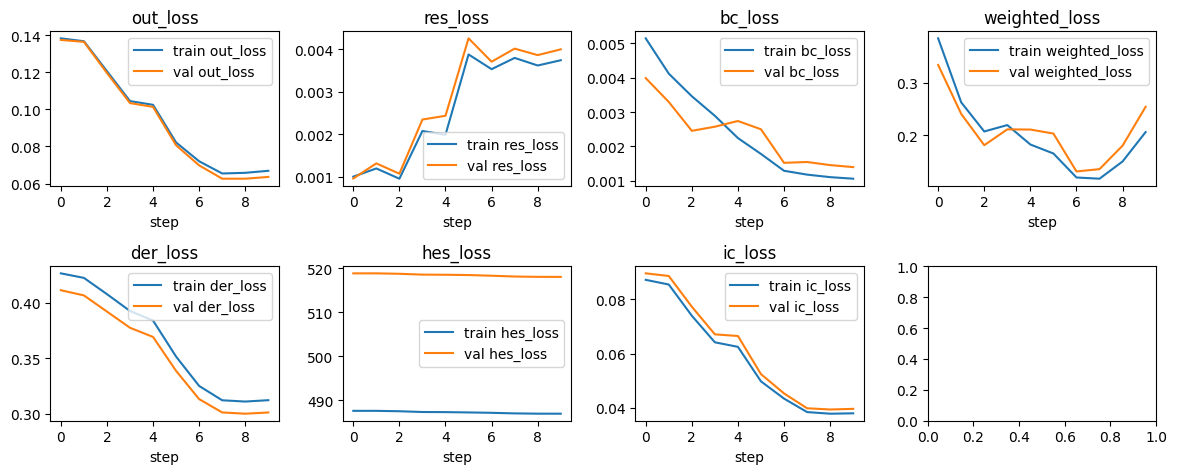


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 132.16322326660156
	IC: 1.2970916032791138
	RES: 4.580784797668457
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
--------------------

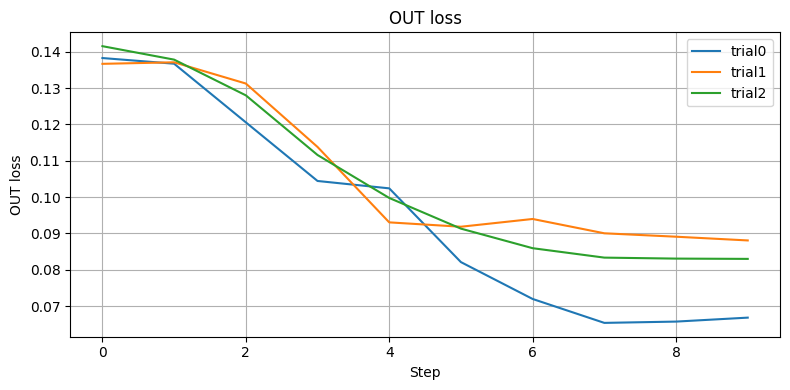

In [6]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

### 2nd model selection step
Take the best 3 trials/configurations and perform 50 epochs of training for each of them.

In [7]:
if TRAIN:
    n_best = 3
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"

    fourier_features = []
    lr_init = []

    for i in range(n_best):
        checkpoint = torch.load(f"{models_dir}/trial{i}/model.pth", weights_only=False)
        fourier_features.append(checkpoint["fourier_features"])
        lr_init.append(checkpoint["lr_init"])

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"

    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = min(50, N_EPOCHS)
    config_dict["n_trials"] = 3
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000

    if FOURIER_FEATURES:
        actual["fourier_features"] = fourier_features
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    
    if not ONLY_FINAL_TRAINING:
        start_train(config_dict)

[I 2026-04-13 16:50:55,496] A new study created in memory with name: no-name-bf72cb88-a48e-4717-8b04-0ba3fbea27b4


batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 608
len(train_bc_dataset) = 608
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 196
len(val_bc_dataset) = 196

Epoch: 0, step_prefix: 0
Epoch time: 1.8302555084228516
train weighted loss: 0.23410615644284657
train out loss: 0.13590367989880697
val weighted loss: 0.20947140082716942
val out loss: 0.1349738873541355

Epoch: 1, step_prefix: 14
Epoch time: 1.5167508125305176
train weighted loss: 0.18483272514172963
train out loss: 0.125459402267422
val weighted loss: 0.16983357444405556
val out loss: 0.12446490861475468

Epoch: 2, step_prefix: 28
Epoch time: 1.9023065567016602
train weighted loss: 0.20043371617794037
train out loss: 0.09731068462133408
val weighted loss: 0.17008863016963005
val out loss: 0.09608214721083641

Epoch: 3, step_prefix: 42
Epoch time: 1.7486767768859863
train weighted 

[I 2026-04-13 16:53:22,572] Trial 0 finished with value: 0.0032566680893069133 and parameters: {}. Best is trial 0 with value: 0.0032566680893069133.


val weighted loss: 0.027119864709675312
val out loss: 0.002561793487984687
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 608
len(train_bc_dataset) = 608
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 196
len(val_bc_dataset) = 196

Epoch: 0, step_prefix: 0
Epoch time: 1.5186958312988281
train weighted loss: 1.4388095055307661
train out loss: 0.14592416797365462
val weighted loss: 1.2579241693019867
val out loss: 0.14449873194098473

Epoch: 1, step_prefix: 14
Epoch time: 1.357710361480713
train weighted loss: 0.5315354083265577
train out loss: 0.13422686819519317
val weighted loss: 0.48614924401044846
val out loss: 0.13409611582756042

Epoch: 2, step_prefix: 28
Epoch time: 1.4845945835113525
train weighted loss: 0.2638721742800304
train out loss: 0.12420853812779699
val weighted loss: 0.25916413962841034
val out loss: 0.1222639475017786



[I 2026-04-13 16:55:47,425] Trial 1 finished with value: 0.004233463201671839 and parameters: {}. Best is trial 0 with value: 0.0032566680893069133.


val weighted loss: 0.04200644511729479
val out loss: 0.003741420921869576
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 608
len(train_bc_dataset) = 608
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 196
len(val_bc_dataset) = 196

Epoch: 0, step_prefix: 0
Epoch time: 1.4589416980743408
train weighted loss: 1.337074611868177
train out loss: 0.14169830828905106
val weighted loss: 1.0976475179195404
val out loss: 0.14015886560082436

Epoch: 1, step_prefix: 14
Epoch time: 1.3412504196166992
train weighted loss: 0.5104644170829228
train out loss: 0.13456480205059052
val weighted loss: 0.43765591084957123
val out loss: 0.13396159932017326

Epoch: 2, step_prefix: 28
Epoch time: 1.4839999675750732
train weighted loss: 0.3053457183497293
train out loss: 0.11748626987848963
val weighted loss: 0.2676488980650902
val out loss: 0.11647438257932663

E

[I 2026-04-13 16:58:14,512] Trial 2 finished with value: 0.03978102936525829 and parameters: {}. Best is trial 0 with value: 0.0032566680893069133.


val weighted loss: 1.0031442046165466
val out loss: 0.06275229435414076
Best trial params: {}
Best trial value: 0.0032566680893069133
trialN0 --> trial0: Objective Value = 0.0033
trialN1 --> trial1: Objective Value = 0.0042
trialN2 --> trial2: Objective Value = 0.0398


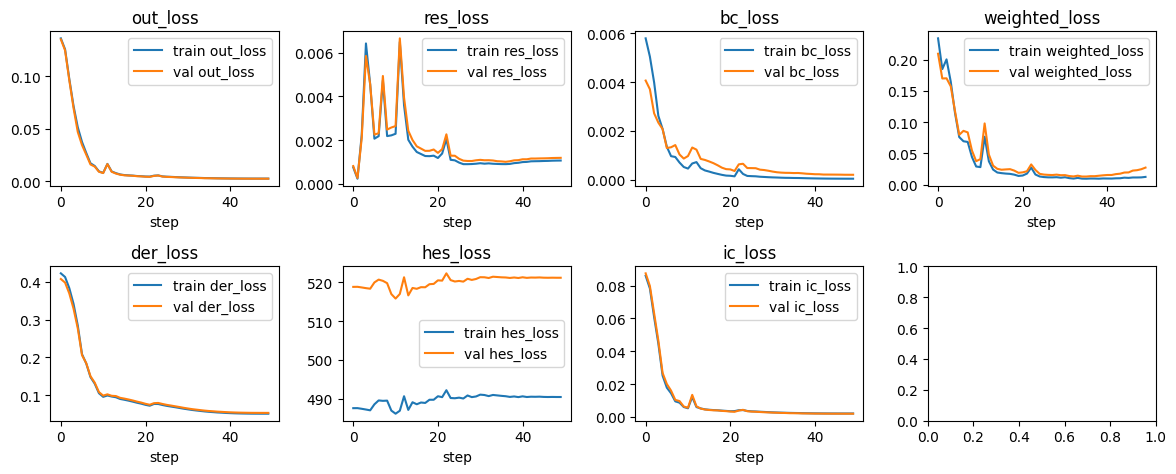


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 94.30099487304688
	IC: 3.352313756942749
	RES: 1.5456311702728271
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
---------------------

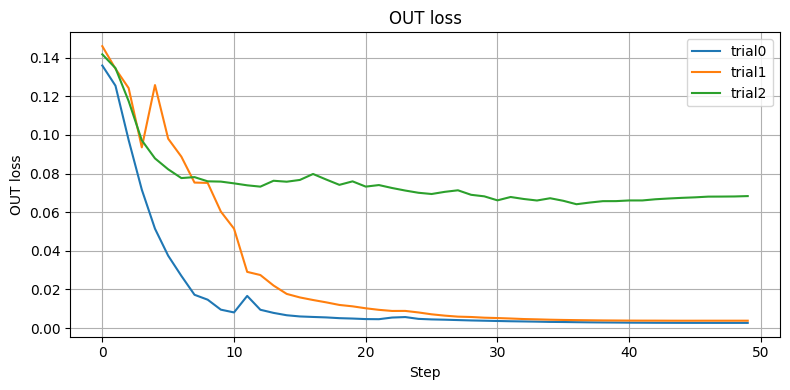

In [8]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

### 3rd model selection step
Take the best trial/configuration and perform 100 epochs of training.

In [9]:
if TRAIN:
    if train_dataset is not None:
        del train_dataset
        train_dataset = None
    if val_dataset is not None:
        del val_dataset
        val_dataset = None
    if INDEX is None:
        full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
    else:
        full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]
    dev_dataset = load_datasets(full_dataset, indices["dev"], TIME_RESOLUTION)
    del full_dataset
    full_dataset = None
    
    dev_dataset = prepare_dataset(datasets=dev_dataset, time_instants=TIME_INDEXES)

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
    
    checkpoint = torch.load(f"{models_dir}/trial{0}/model.pth", weights_only=False)
    fourier_features = checkpoint["fourier_features"]
    lr_init = checkpoint["lr_init"]
    
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = N_EPOCHS
    config_dict["n_trials"] = 1
    
    actual["fourier_features"] = fourier_features
    actual["train_dataset"] = dev_dataset
    actual["val_dataset"] = ""
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    config_dict["batch_size"] = min(BATCH_SIZE_DEV, len(dev_dataset))
    start_train(config_dict)

[I 2026-04-13 16:58:19,384] A new study created in memory with name: no-name-79a3ad92-10c0-4e0c-bba9-9bb5a548c421


batch_size_train = 1024
len(train_dataset) = 19456
batch_size_train_ic = 1024
len(train_ic_dataset) = 2048
batch_size_train_bc = 804
len(train_bc_dataset) = 804

Epoch: 0, step_prefix: 0
Epoch time: 2.1479554176330566
train weighted loss: 0.21816269504396538
train out loss: 0.1339145228266716

Epoch: 1, step_prefix: 19
Epoch time: 2.4060990810394287
train weighted loss: 0.1876089196456106
train out loss: 0.10451758966634148

Epoch: 2, step_prefix: 38
Epoch time: 2.1331937313079834
train weighted loss: 0.16925302147865295
train out loss: 0.08653660275434193

Epoch: 3, step_prefix: 57
Epoch time: 3.0367612838745117
train weighted loss: 0.2544032539191999
train out loss: 0.05619178673154429

Epoch: 4, step_prefix: 76
Epoch time: 2.881948709487915
train weighted loss: 0.06459354609251022
train out loss: 0.03036221254028772

Epoch: 5, step_prefix: 95
Epoch time: 2.170119047164917
train weighted loss: 0.06298012600133293
train out loss: 0.02288254468064559

Epoch: 6, step_prefix: 114
Epoch t

[I 2026-04-13 17:21:30,078] Trial 0 finished with value: 7.686908213599963e-05 and parameters: {}. Best is trial 0 with value: 7.686908213599963e-05.


train weighted loss: 0.00036875689310315803
train out loss: 8.142536013397866e-06
Best trial params: {}
Best trial value: 7.686908213599963e-05
trialN0 --> trial0: Objective Value = 0.0001


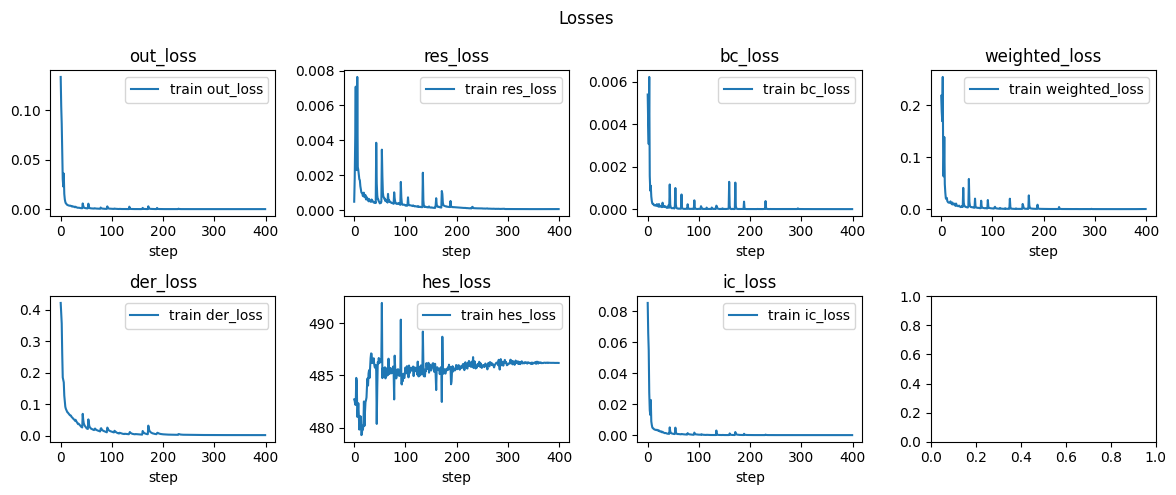


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 143.95657348632812
	IC: 5.01370096206665
	RES: 1.366447925567627
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
----------------------

In [10]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    title="Losses",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

Last res_loss: 5.7281846238765866e-05
Last bc_loss: 1.3838758832207532e-06
Last ic_loss: 1.820335819502361e-05
Last grad norm: 0.005208512302488089


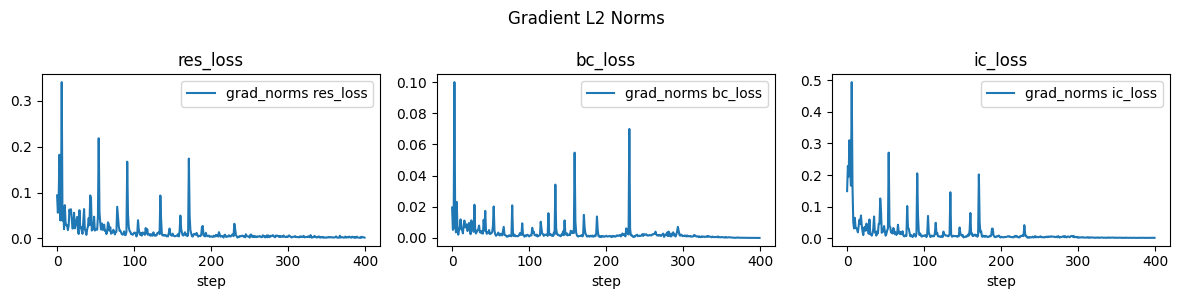

Last value weights res_loss: 1.366447925567627
Last value weights bc_loss: 143.95657348632812
Last value weights ic_loss: 5.01370096206665


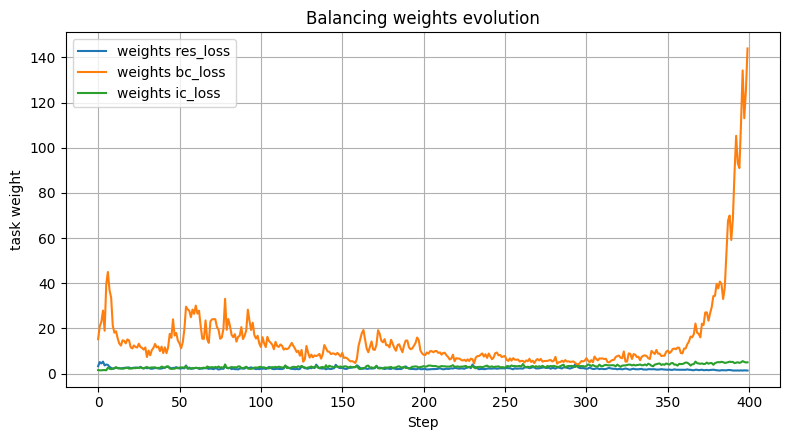

Last value conflicts bc_loss: -0.21944957971572876
Last value conflicts ic_loss: 0.08864407241344452


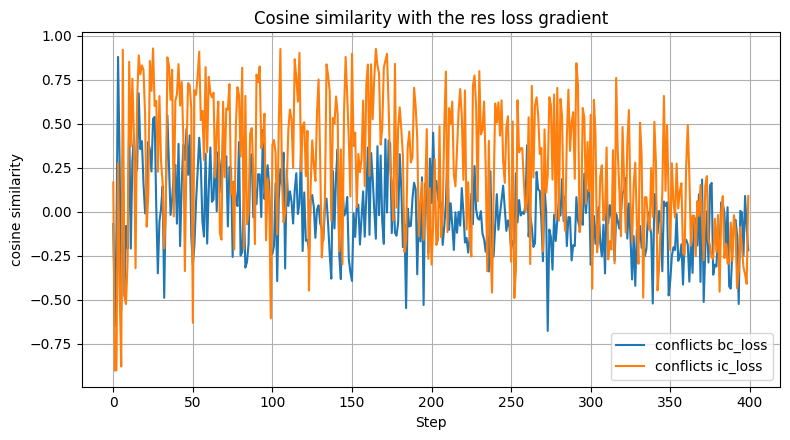

In [11]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

print(f"Last res_loss: {models_dict['trial0']['train']['res_loss'][-1]}")
print(f"Last bc_loss: {models_dict['trial0']['train']['bc_loss'][-1]}")
print(f"Last ic_loss: {models_dict['trial0']['train']['ic_loss'][-1]}")
print(f"Last grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["grad_norms"],
    subkeys=["res_loss", "bc_loss", "ic_loss"],
    figsize=(12, 3),
    title="Gradient L2 Norms",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/grad_norms.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss", "bc_loss", "ic_loss"],
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=["bc_loss", "ic_loss"],
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

### Predictions vs real values

Params 4


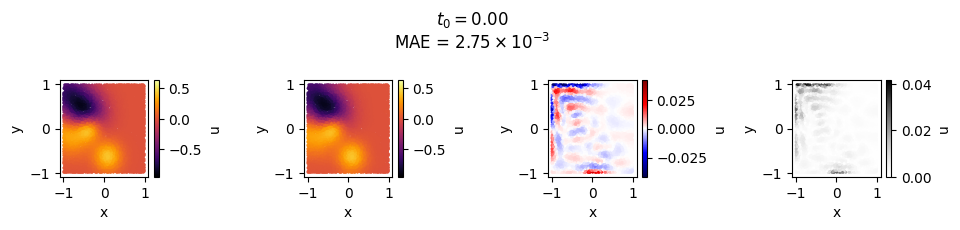

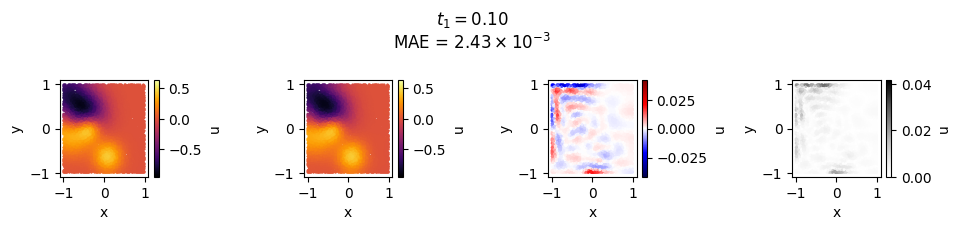

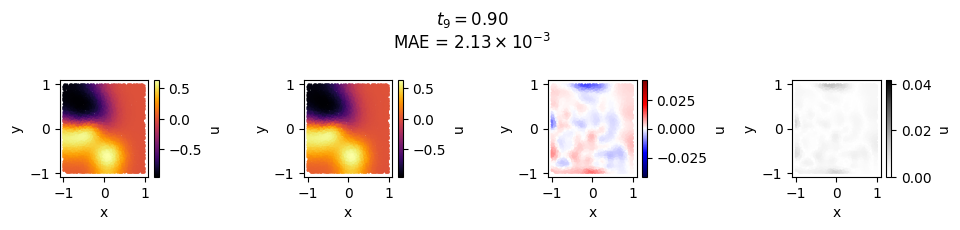

In [12]:
if CROSS_THE_RUBICON:
    times = [0, 1, 9]
    param_indices = [INDEX] # [D_INDEX] [IC_INDEX]

    if "IC" in FIXED and "D" in FIXED:
        param_indices = [INDEX]

    if dev_dataset is not None:
        del dev_dataset
        dev_dataset = None
    datasets = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets

    trues = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]
    
    for i in param_indices:
        trues[i] = datasets[i].datasets
    del datasets

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([trues[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([trues[i][t].tensors[U].max() for t in times]))
    vmin = min(vmins)
    vmax = max(vmaxs)

    differences = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]

    for i in param_indices:
        for t in times:
            differences[i][t] = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=True)

    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([differences[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([differences[i][t].tensors[U].max() for t in times]))
    vmin_diff = min(vmins)
    vmax_diff = max(vmaxs)
    v_diff = max(abs(vmin_diff), abs(vmax_diff))

    figsize = (9.8, 2.3)
    
    for i in param_indices:
        print(f"Params {i}")
        for t in times:

            prediction = compute_prediction(model=best_model, dataset=trues[i][t])
            abs_difference = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=False)
            mean_abs_difference = torch.mean(abs_difference.tensors[U])
            mae = mean_abs_difference.item()

            value = format(mae, ".2e").split('e')[0]
            exponent = format(mae, ".2e").split('e')[1]

            plot_points(
                dataset=[trues[i][t], prediction, differences[i][t], abs_difference],
                points_idx=X,
                labels_idx=U,
                cmap=["inferno", "inferno", "seismic", "Greys"],
                figsize=figsize,
                vmin=2*[vmin]+[-v_diff]+[0],
                vmax=2*[vmax]+[v_diff]+[v_diff],
                title=f"$t_{{{t}}} = {{{trues[i][t].tensors[TIMES][0].item():.2f}}}$\nMAE = ${{{value}}} \\times 10^{{{int(exponent)}}}$",
                save=True,
                dst_file=f"{models_dir}/plots/Task{i}Time{t}.png",
                show=True
            )

In [13]:
if CROSS_THE_RUBICON and False:
    param_indices = [0, 1, 2] # [D_INDEX] [IC_INDEX]

    if "IC" in FIXED and "D" in FIXED:
        param_indices = [INDEX]

    if dev_dataset is not None:
        del dev_dataset
        dev_dataset = None
    dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
    dataset = [dataset[i] for i in param_indices]

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    for j, cds in tqdm(zip(param_indices, dataset), total=len(param_indices)):
        trues = []
        predictions = []
        differences = []
        for i in range(0, len(cds.datasets)):
            ds = cds.datasets[i]
            trues.append(ds)
            predictions.append(compute_prediction(model=best_model, dataset=ds))
            differences.append(compute_prediction_difference(model=best_model, dataset=ds, signed=False))
        get_animation(dataset=ConcatDataset(trues), figsize=(2, 1.5), filename=f"{models_dir}/plots/true{j}a.gif", save=True)
        get_animation(dataset=ConcatDataset(predictions), figsize=(2, 1.5), filename=f"{models_dir}/plots/predicted{j}a.gif", save=True)
        get_animation(dataset=ConcatDataset(differences), figsize=(2, 1.5), filename=f"{models_dir}/plots/difference{j}a.gif", save=True, cmap="Greys")

        #get_animation(dataset=ConcatDataset(trues[1:]), filename=f"{models_dir}/plots/true{j}b.gif", save=True)
        #get_animation(dataset=ConcatDataset(predictions[1:]), filename=f"{models_dir}/plots/predicted{j}b.gif", save=True)
        #get_animation(dataset=ConcatDataset(differences[1:]), filename=f"{models_dir}/plots/difference{j}b.gif", save=True, cmap="Greys")

        